<a href="https://colab.research.google.com/github/AIML-Dept/RithikaRajavel_1GA23AI041/blob/main/WEEK_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 4 - Easy: CNOT Gate

## Objective

Implement a two-qubit CNOT gate with the control qubit in the
|1⟩ state and verify that the target qubit flips.

A CNOT gate flips the target qubit only when the control qubit
is in the |1⟩ state.

In [2]:
import sys
!{sys.executable} -m pip install qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00


## Step 1: Create the Two-Qubit Circuit

We create a circuit containing two qubits.

The first qubit will be used as the control qubit and the
second qubit will be used as the target qubit.

In [3]:
qc = QuantumCircuit(2)

print(qc)

     
q_0: 
     
q_1: 
     


In [4]:

qc.x(0)

print(qc)

     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
          


## Step 3: Apply the CNOT Gate

The first qubit is the control and the second qubit is the target.

Since the control qubit is |1⟩, the CNOT gate flips the target
qubit from |0⟩ to |1⟩.

In [5]:
qc.cx(0, 1)

print(qc)

     ┌───┐     
q_0: ┤ X ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


## Step 4: Verify the Final State

We use the statevector to verify the result of the circuit.

The expected final state is:

|11⟩

In [6]:
state = Statevector.from_instruction(qc)

print("Final Statevector:")
print(state)

Final Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


## Conclusion

The control qubit was changed from |0⟩ to |1⟩ using an X gate.

When the CNOT gate was applied, the target qubit flipped from
|0⟩ to |1⟩.

Therefore, the final state was:

|11⟩

This demonstrates the control-target relationship of the CNOT gate.

# Tutorial 4 - Medium: Bell State

## Objective

Create a Bell state using a Hadamard gate and a CNOT gate.

The circuit should generate the entangled state:

|Φ+⟩ = (|00⟩ + |11⟩) / √2

When measured, the expected outcomes are only 00 and 11.

In [8]:
import sys
!{sys.executable} -m pip install qiskit-aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.7 MB/s eta 0:00:00


## Step 1: Create the Circuit

We create a two-qubit circuit with two classical bits
for measurement.

In [9]:
qc = QuantumCircuit(2, 2)

print(qc)

     
q_0: 
     
q_1: 
     
c: 2/
     


## Step 2: Create Superposition

A Hadamard gate is applied to the first qubit.

This creates a superposition of |0⟩ and |1⟩.

In [10]:
qc.h(0)

print(qc)

     ┌───┐
q_0: ┤ H ├
     └───┘
q_1: ─────
          
c: 2/═════
          


## Step 3: Create Entanglement

A CNOT gate is applied with qubit 0 as the control
and qubit 1 as the target.

This produces the Bell state.

In [11]:
qc.cx(0, 1)

print(qc)

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               


## Step 4: Measure the Qubits

The two qubits are measured 1024 times to observe
the possible outcomes.

In [12]:
qc.measure([0, 1], [0, 1])

simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)

counts = job.result().get_counts()

print(counts)

{'11': 512, '00': 512}


## Step 5: Visualize the Results

The histogram shows that the measurement results
are concentrated around 00 and 11.

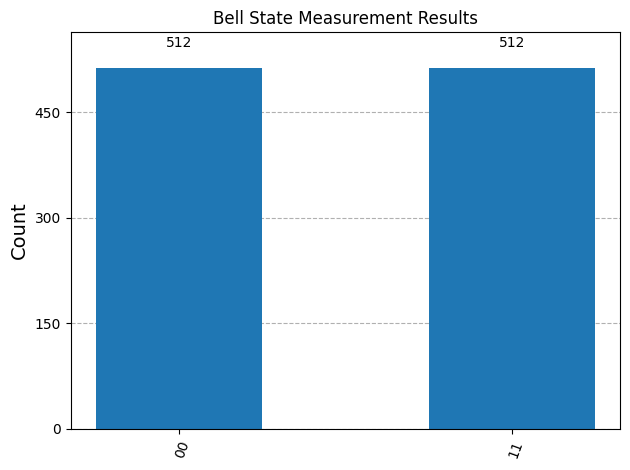

In [13]:
plot_histogram(
    counts,
    title="Bell State Measurement Results"
)

## Conclusion

The circuit generated an entangled Bell state.

The measurement results were only 00 and 11, with approximately
equal probabilities.

This demonstrates quantum entanglement between two qubits.

# Tutorial 4 - Hard: Three-Qubit GHZ State

## Objective

Create a three-qubit GHZ state and verify perfect
three-way correlation through measurement.

The expected state is:

|GHZ⟩ = (|000⟩ + |111⟩) / √2

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Step 1: Create the Three-Qubit Circuit

Three qubits and three classical bits are created
for the GHZ experiment.

In [15]:
qc = QuantumCircuit(3, 3)

print(qc)

     
q_0: 
     
q_1: 
     
q_2: 
     
c: 3/
     


In [16]:
qc.h(0)

In [17]:
qc.cx(0, 1)
qc.cx(0, 2)

print(qc)

     ┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
c: 3/═══════════════
                    


In [18]:
qc.measure([0, 1, 2], [0, 1, 2])

simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)

counts = job.result().get_counts()

print(counts)

{'000': 504, '111': 520}


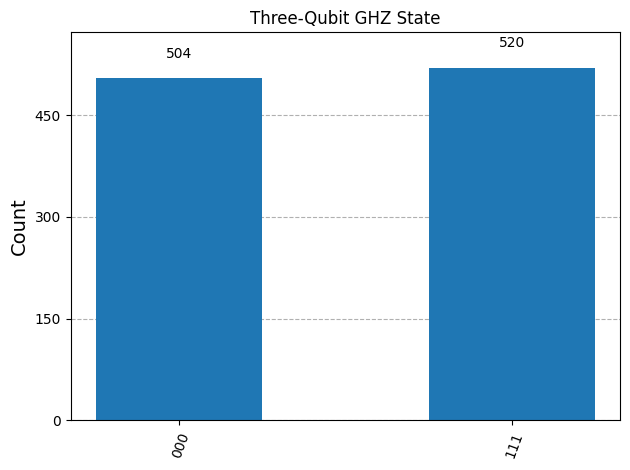

In [19]:
plot_histogram(
    counts,
    title="Three-Qubit GHZ State"
)

## Conclusion

The GHZ circuit generated strong three-way correlation.

The measurement results are expected to contain only 000 and 111,
with approximately equal probabilities.

This demonstrates entanglement involving three qubits.

# Tutorial 4 - Real World: Quantum Full Adder

## Objective

Emulate a classical full-adder circuit using quantum gates.

A full adder takes three input bits:

A, B and Cin

and produces:

Sum = A XOR B XOR Cin

Carry = AB XOR Cin(A XOR B)

CNOT gates are used for XOR operations and Toffoli gates
are used to generate carry information.

In [20]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [21]:
qc = QuantumCircuit(5)

A = 0
B = 1
Cin = 2
Sum = 3
Carry = 4

In [22]:
qc.x(A)
qc.x(B)

print(qc)

     ┌───┐
q_0: ┤ X ├
     ├───┤
q_1: ┤ X ├
     └───┘
q_2: ─────
          
q_3: ─────
          
q_4: ─────
          


In [23]:
qc.cx(A, Sum)
qc.cx(B, Sum)
qc.cx(Cin, Sum)

In [24]:
qc.ccx(A, B, Carry)

print(qc)

     ┌───┐                    
q_0: ┤ X ├──■──────────────■──
     ├───┤  │              │  
q_1: ┤ X ├──┼────■─────────■──
     └───┘  │    │         │  
q_2: ───────┼────┼────■────┼──
          ┌─┴─┐┌─┴─┐┌─┴─┐  │  
q_3: ─────┤ X ├┤ X ├┤ X ├──┼──
          └───┘└───┘└───┘┌─┴─┐
q_4: ────────────────────┤ X ├
                         └───┘


In [25]:
state = Statevector.from_instruction(qc)

print("Final Statevector:")
print(state)

Final Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2))


# Tutorial 4 - Challenge: Arbitrary Two-Qubit Entangled State

## Objective

Create a two-qubit entangled state that is different from
the standard Bell states.

The target state is:

|ψ⟩ = cos(θ)|00⟩ + sin(θ)|11⟩

For this experiment, θ = π/6.

The resulting statevector will be inspected to verify
the amplitudes of the entangled state.

In [26]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [27]:
theta = np.pi / 3

qc = QuantumCircuit(2)

qc.ry(theta, 0)
qc.cx(0, 1)

print(qc)

     ┌─────────┐     
q_0: ┤ Ry(π/3) ├──■──
     └─────────┘┌─┴─┐
q_1: ───────────┤ X ├
                └───┘


In [28]:
state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

Statevector:
Statevector([0.8660254+0.j, 0.       +0.j, 0.       +0.j, 0.5      +0.j],
            dims=(2, 2))


In [29]:
probabilities = state.probabilities_dict()

print("State Probabilities:")

for state_name, probability in probabilities.items():
    print(f"{state_name}: {probability:.3f}")

State Probabilities:
00: 0.750
11: 0.250


In [30]:
total = sum(probabilities.values())

print(f"Total Probability: {total:.3f}")

Total Probability: 1.000


## Conclusion

A two-qubit entangled state was created using a rotation
gate and a CNOT gate.

The statevector was inspected to verify the amplitudes,
and the probabilities were checked to ensure that the
quantum state is normalized.

This demonstrates how different two-qubit entangled states
can be constructed by changing the rotation angle.